### Colab setup

Run the cell below first. It installs the packages Colab does not ship with
(`numpy`, `scipy`, `sympy`, `matplotlib`, `pandas` and `scikit-learn` are
already there). Figures are
loaded from the course site, so this notebook needs a network connection --
the copy in the repo is the one to use offline.


In [ ]:
%pip install -q control


# PSE-823: Advanced Process Dynamics and Control
## Lecture 10 -- Controller Tuning and Process Identification
### (Coughanowr & LeBlanc, Ch. 18)

Date: __________

## Agenda

**Part A** -- Figures of merit; Ziegler-Nichols and Cohen-Coon
(Sec. 18.1-18.2)

**Part B** -- Step, pulse and doublet testing (Sec. 18.3)

**Part C** -- A model from data by least squares: ARX

**Part D** -- First machine-learning model: does it work for control?

### Setup (run once)

- The standard imports, an optimizer, pandas and scikit-learn

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
import control as ct
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit
plt.rcParams.update({"font.size": 15})
from scipy.optimize import minimize
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

## Part A
### Figures of Merit and Tuning Rules

(Coughanowr & LeBlanc, Ch. 18, Sec. 18.1-18.2)
<!-- source: coughanowr-ch18 -->

### Introduce -- which response is "best"? (Sec. 18.1)

- One number per transient, from the error $e(t)$:
- $ISE = \int_0^\infty e^2\,dt$ -- punishes large early errors
  (Eq. 18.1)
- $IAE = \int_0^\infty |e|\,dt$ -- all errors alike (Eq. 18.2)
- $ITAE = \int_0^\infty t|e|\,dt$ -- punishes errors that linger
  (Eq. 18.3)
- Lower is better; the numbers mean something only when compared.

### Introduce -- two tuning rules (Sec. 18.2)

- **Ziegler-Nichols** (closed loop): raise $K_c$ under P control until
  the loop cycles; read $K_{cu}$, $P_u$; use Table 18.1. Beware a
  *limit cycle* from a saturated valve: not the ultimate gain.
- **Cohen-Coon** (open loop): step the valve in manual, record the
  S-shaped *process reaction curve*, fit
  $\dfrac{K_pe^{-T_ds}}{Ts + 1}$, use Table 18.2.
- Ex. 18.4: the process $1/(s + 1)^4$; PI control.

### Derive 1/2 -- Z-N for $1/(s+1)^4$

Phase $= -4\tan^{-1}\omega = -180^\circ$:

$\omega_{co} = 1$, $AR = (1/\sqrt2)^4 = 1/4$, so $K_{cu} = 4$,
$P_u = 2\pi$. PI (Table 18.1): $K_c = 0.45(4) = 1.8$,
$\tau_I = 2\pi/1.2 = 5.24$.

### Derive 2/2 -- C-C from the tangent (Fig. 18-6)

Step response $c = 1 - e^{-t}(1 + t + t^2/2 + t^3/6)$; slope $c' = t^3e^{-t}/6$:

Steepest at $c'' = 0$: $t = 3$, $S = 4.5e^{-3} = 0.224$, $c(3) = 0.353$.
Tangent hits zero at $T_d = 3 - 0.353/0.224 = 1.42$; $T = B_u/S = 4.46$
(Eq. 18.4). Table 18.2 PI: $K_c = \frac{T}{K_pT_d}(0.9 + \frac{T_d}{12T})
= 2.91$, $\tau_I = T_d\frac{30 + 3T_d/T}{9 + 20T_d/T} = 2.86$.

### Code 1/4 -- the tangent construction, numerically

- Mirrors Derive 2/2 on a simulated reaction curve
- The inflection point is where the slope is largest

In [2]:
G = ct.tf([1], [1, 4, 6, 4, 1])            # 1/(s+1)^4
t = np.linspace(0, 30, 3001)
c = ct.step_response(G, t).outputs
S = np.gradient(c, t)                      # slope at every point
i = S.argmax()                             # inflection point
Td, T = t[i] - c[i] / S[i], 1 / S[i]       # tangent; Eq. 18.4
print(f"t = {t[i]:.2f}, c = {c[i]:.3f}, S = {S[i]:.3f}, "
      f"Td = {Td:.2f}, T = {T:.2f}")

t = 3.00, c = 0.353, S = 0.224, Td = 1.43, T = 4.46


**Code walkthrough.** `G` is (s + 1)^4 expanded: coefficients 1, 4, 6, 4, 1. `np.gradient`
returns the slope dc/dt at every sample (central differences);
`argmax` gives the index of the largest slope -- the inflection point.
The tangent through (t_i, c_i) with slope S reaches c = 0 at
t_i - c_i/S: that is Td. With Bu = 1, T = 1/S. Prints t = 3.00,
c = 0.353, S = 0.224, Td = 1.43, T = 4.46: Derive 2/2, now measured
from the curve instead of from the formula.

### Code 2/4 -- the two rules as functions

- Table 18.1 (PI row) and Table 18.2 (PI row)

In [3]:
def zn_pi(Kcu, Pu):
    return 0.45 * Kcu, Pu / 1.2
def cc_pi(Kp, T, Td):
    r = Td / T
    return T / (Kp * Td) * (0.9 + r / 12), Td * (30 + 3*r) / (9 + 20*r)
tunings = {"Z-N": zn_pi(4, 2 * np.pi), "C-C": cc_pi(1, T, Td)}
print({k: tuple(round(float(x), 2) for x in v)
       for k, v in tunings.items()})

{'Z-N': (1.8, 5.24), 'C-C': (2.9, 2.87)}


**Code walkthrough.** Each function returns the pair (Kc, tau_I). `cc_pi` writes r = Td/T
once to keep the formulas short. The dictionary `tunings` holds both
results, keyed by method; the last line rounds them for printing.
Prints Z-N (1.8, 5.24) and C-C (2.9, 2.87); the book's 2.91, 2.86
use Td and T rounded to 1.42 and 4.46.

### Code 3/4 -- score a tuning: load response and merits

- Load step: $C/U = G/(1 + G_cG)$ (as in Table 18.5)
- The three integrals by the trapezoid rule

In [4]:
t = np.linspace(0, 40, 4001)
def load_resp(Kc, tI):
    Gc = Kc * ct.tf([tI, 1], [tI, 0])      # PI: Kc (tI s + 1)/(tI s)
    return ct.step_response(ct.feedback(G, Gc), t).outputs
def merits(e):                             # ITAE, IAE, ISE
    return [np.trapezoid(f, t) for f in (t * abs(e), abs(e), e**2)]
for k, v in tunings.items():
    print(k, np.round(merits(-load_resp(*v)), 2))

Z-N [23.76  2.92  0.82]
C-C [299.78  12.69   5.58]


**Code walkthrough.** `ct.feedback(G, Gc)` is G/(1 + G Gc): the load (disturbance entering
before G) to output transfer function. The set point is zero, so the
error is e = 0 - c = -c. `np.trapezoid` integrates sampled data.
Z-N: ITAE 23.8, IAE 2.92, ISE 0.82 (book 24.2 and 2.93). C-C: ITAE
300 and climbing -- the loop is unstable (book: 8431 over a longer
run). The graphical tangent overestimated the steepness of an S that
is really four lags.

### Code 4/4 -- see it (Fig. 18-15)

- Load responses for Z-N and C-C

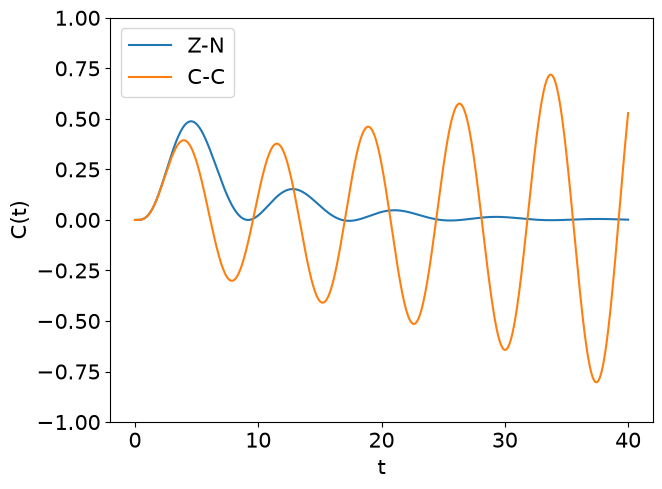

In [5]:
fig, ax = plt.subplots(figsize=(7, 5.25))
for k, v in tunings.items():
    ax.plot(t, load_resp(*v), label=k)
ax.set(xlabel="t", ylabel="C(t)", ylim=(-1, 1)); ax.legend()
plt.show()

**Code walkthrough.** Both responses to a unit load step. Z-N peaks near 0.49 and settles
back to zero in about 25 time units (integral action: no offset). C-C
oscillates with growing amplitude, near 0.8 by t = 40: an unstable
loop, as the ITAE said.

### Build on it -- tune by minimizing ITAE (Table 18.5)

- Let an optimizer search $(K_c, \tau_I)$ from the Z-N start

In [ ]:
best = minimize(lambda p: merits(-load_resp(*p))[0],
                x0=tunings["Z-N"], method="Nelder-Mead")
print(f"min ITAE: Kc = {best.x[0]:.2f}, tI = {best.x[1]:.2f}, "
      f"ITAE = {best.fun:.2f}")

**Code walkthrough.** `minimize` takes a function of the parameter vector p = (Kc, tau_I)
and returns the p that makes it smallest; `[0]` picks ITAE from the
three merits. Nelder-Mead needs no derivatives, only function values
-- each one a closed-loop simulation. Prints Kc = 1.18, tI = 3.29,
ITAE = 19.32: Table 18.5's 1.18, 3.28, 19.37. This is what the book
did with MATLAB's FMINSEARCH (Ex. 18.2).

### Your Turn (8 min)

1. By hand: Z-N PI for $K_{cu} = 6.75$, $P_u = 3.77$ min (Lecture 8).
2. Read the code: what does this print?

```python
e = np.array([0.0, 1.0, -1.0, 0.0])
print(np.trapezoid(abs(e), dx=1.0), np.trapezoid(e, dx=1.0))
```

Why must IAE use `abs`?

(1) Kc = 3.04, tau_I = 3.14 min.
(2) 2.0 0.0. The plain integral of e cancels positive and negative
errors: an oscillating response would score zero. abs (or squaring)
prevents the cancellation.

### Check -- cold-call

During a Z-N test the valve hits 3 psig and 15 psig on every cycle and
the oscillation holds steady. Do you record $K_{cu}$ and $P_u$?

No. That is a limit cycle caused by valve saturation, a nonlinear
effect (Sec. 18.2 precautions): the gain and period are not the
ultimate values. Use smaller disturbances and raise Kc in small steps.

## Part B
### Step, Pulse and Doublet Testing

(Coughanowr & LeBlanc, Ch. 18, Sec. 18.3)
<!-- source: coughanowr-ch18 -->

### Introduce -- identification from a test

- No first-principles model? **Excite the process and fit one.**
- Step test: simple; ties the plant up for one transient.
- Pulse test: output returns to its start; least disruptive.
- Doublet (Fig. 18-23): pulse up, then pulse down -- e.g. valve
  50 -> 60 -> 40 -> 50%. Data on both sides of the operating point.
- Fit by least squares instead of a tangent (the LOOP-PRO fits).

### Derive 1/2 -- the FOPDT step response

Invert $\dfrac{K_p e^{-T_ds}}{Ts + 1}\cdot\dfrac{M}{s}$:

$$y(t) = K_pM\left(1 - e^{-(t - T_d)/T}\right)\ \text{for } t > T_d,
\quad 0 \text{ before}$$

Least squares: choose $(K_p, T, T_d)$ to minimize
$SSE = \sum_k [y_k^{data} - y(t_k)]^2$.

### Derive 2/2 -- pulses by superposition

A pulse of height $M$ and width $w$ is a step up then a step down:

$u(t) = M[S(t) - S(t - w)]$, so $y_{pulse}(t) = y_{step}(t) -
y_{step}(t - w)$. A doublet adds $-2M$ at $w$ and $+M$ at $2w$. The
same model, any input: fit against whatever input was applied.

### Code 1/3 -- least-squares FOPDT for Ex. 18.4

- Mirrors Derive 1/2; `curve_fit` minimizes the SSE

In [7]:
def fopdt_step(t, K, T, Td):
    return K * (1 - np.exp(-np.clip(t - Td, 0, None) / T))
ts = np.linspace(0, 20, 2001)
c = ct.step_response(G, ts).outputs
p, _ = curve_fit(fopdt_step, ts, c, p0=[1, 3, 1])
print("K, T, Td =", np.round(p, 2))
print("C-C PI on the fit:", np.round(cc_pi(*p), 2))

K, T, Td = [1.01 2.46 1.79]
C-C PI on the fit: [1.3  2.45]


**Code walkthrough.** `fopdt_step` is Derive 1/2 with M = 1; `np.clip(t - Td, 0, None)` sets
negative times to zero, so the response is 0 before the dead time.
`curve_fit(f, x, y, p0)` adjusts the parameters after x to minimize
the sum of squared residuals, starting from p0, and returns them with
their covariance (discarded as `_`). Prints K = 1.01, T = 2.46,
Td = 1.79 (LOOP-PRO: 1.03, 2.65, 1.79). C-C on this fit: Kc = 1.30,
tI = 2.45 (book, on its fit: 1.374, 2.548) -- a stable loop this
time.

### Code 2/3 -- pulse and doublet on a black box (Ex. 18.6)

- Black box $2/[(s + 1)(2s + 1)(0.5s + 1)]$, 5-min pulses
- Fit the same FOPDT to each test

In [8]:
box = ct.tf([2], np.polymul(np.polymul([1, 1], [2, 1]), [0.5, 1]))
tb = np.linspace(0, 30, 3001)
tests = {"pulse": np.where(tb < 5, 1.0, 0.0),
         "doublet": np.where(tb < 5, 1.0, np.where(tb < 10, -1.0, 0.0))}
def fopdt_any(u, K, T, Td):                   # any input u(t)
    u_late = np.interp(tb - Td, tb, u, left=0)  # dead time: shift u
    return ct.forced_response(ct.tf([K], [T, 1]), tb, u_late).outputs
fits = {k: curve_fit(lambda _, *q: fopdt_any(u, *q), tb,
                     ct.forced_response(box, tb, u).outputs,
                     p0=[2, 2.5, 0.6])[0] for k, u in tests.items()}
print({k: np.round(v, 2) for k, v in fits.items()})

{'pulse': array([1.99, 2.52, 1.19]), 'doublet': array([2.07, 2.79, 1.07])}


**Code walkthrough.** `np.polymul` multiplies the three factors' coefficient lists. Each test
is an input array: `np.where` builds the pulse (1 for 5 min) and the
doublet (+1, then -1). `fopdt_any` handles any input -- Derive 2/2 --
by delaying u with `np.interp` (value at t - Td, 0 before the start)
and passing it through K/(Ts + 1). `curve_fit` ignores its x argument
here (`_`); the lambda closes over the input. Pulse: K 1.99, T 2.52,
Td 1.19. Doublet: K 2.07, T 2.79, Td 1.07. Two tests, two models.

### Build on it -- cross-test each model (Fig. 18-27)

- Predict the doublet with both models; compare the SSE

In [ ]:
y_true = ct.forced_response(box, tb, tests["doublet"]).outputs
for k, q in fits.items():
    r = y_true - fopdt_any(tests["doublet"], *q)
    print(f"{k} model on the doublet: SSE = {r @ r:.2f}")

**Code walkthrough.** Both fitted models are driven by the doublet input and compared with
the black box's doublet response. `r @ r` is the sum of squared
residuals. The doublet model wins on the doublet (SSE 8.33 against
10.27 for the pulse model), the book's point: a model fitted with data
from above and below the operating level represents both sides better.

### Your Turn (8 min)

1. By hand: a step of $M = 5\%$ in valve signal moves the output
   $B_u = 12$ units; the steepest slope is 2 units/min and its tangent
   meets the baseline at 1.5 min. Find $K_p$, $T$, $T_d$ (Eqs. 18.4,
   18.5).
2. Read the code: what does `fopdt_step(np.array([0.5, 2.0]), 2, 1, 1)`
   return (two decimals)?

(1) Kp = Bu/M = 2.4 units/%; T = Bu/S = 6 min; Td = 1.5 min.
(2) [0.00, 1.26]: before the dead time 0; at t = 2, 2(1 - e^-1) = 1.26.

### Check -- think-pair-share

The book says the pulse test is the *least disruptive* to the plant,
yet it also says pulse data must be "very accurate and noise-free".
Why does the gentleness cost accuracy?

A small, short pulse barely moves the output, so the response is small
relative to measurement noise; the fit then has little signal to work
with. A larger or longer pulse improves the signal but disturbs the
plant more. Test design is a trade-off.

## Part C
### A Model from Data: ARX by Least Squares

(Coughanowr & LeBlanc, Ch. 18, Sec. 18.3)
<!-- source: coughanowr-ch18 -->

### Introduce -- fit the difference equation directly

- Real tests: noisy data, sampled every $\Delta t$, any input.
- Instead of fitting $y(t)$, fit the **recursion** that generates it.
- ARX (auto-regressive with exogenous input):
  $y_k = a\,y_{k-1} + b\,u_{k-1-d}$.
- Linear in $(a, b)$: one matrix solve, no iterations, no initial guess.

### Derive 1/2 -- FOPDT in discrete time

Hold $u$ constant over one sample in $T\,dy/dt = -y + K_pu$:

$y_k = e^{-\Delta t/T}y_{k-1} + K_p(1 - e^{-\Delta t/T})u_{k-1-d}$
with $d = T_d/\Delta t$. So $a = e^{-\Delta t/T}$,
$b = K_p(1 - a)$, and back: $T = -\Delta t/\ln a$,
$K_p = b/(1 - a)$.

### Derive 2/2 -- the normal equations

Stack one row per sample, $\Phi\theta \approx y$:

$\Phi = \begin{bmatrix} y_{k-1} & u_{k-1-d}\\ \vdots & \vdots
\end{bmatrix}$, $\theta = \begin{bmatrix}a\\ b\end{bmatrix}$.
Minimize $\|y - \Phi\theta\|^2$: set the gradient to zero,
$\Phi^T\Phi\,\theta = \Phi^Ty$.

### Code 1/2 -- a noisy random test on the black box

- Random +/-1 input held 4 min at a time; noise on the measurement

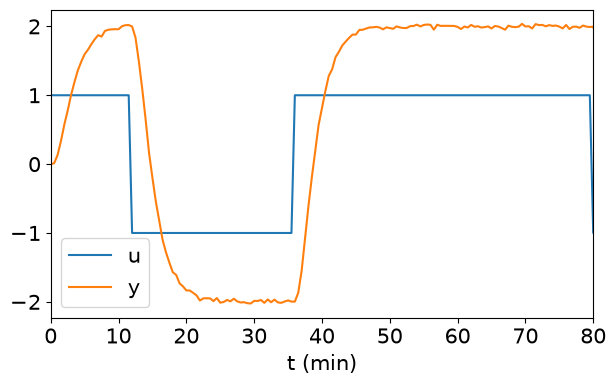

In [10]:
rng = np.random.default_rng(0)
dt = 0.5
tk = np.arange(0, 200, dt)
u = np.repeat(rng.choice([-1.0, 1.0], len(tk) // 8), 8)
y = np.asarray(ct.forced_response(box, tk, u).outputs)
y = y + 0.02 * rng.standard_normal(len(tk))
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(tk, u, label="u"); ax.plot(tk, y, label="y")
ax.set(xlabel="t (min)", xlim=(0, 80)); ax.legend(); plt.show()

**Code walkthrough.** `default_rng(0)` makes the random numbers repeatable. `rng.choice`
draws 50 values of +/-1 and `np.repeat(..., 8)` holds each for 8
samples (4 min): a random binary test signal that excites slow and
fast behaviour. The black box from Part B responds; noise with
standard deviation 0.02 is added. The plot shows the first 80 min.

### Code 2/2 -- solve for $(a, b)$ and recover the FOPDT

- Mirrors Derive 2/2; try dead times of 1, 2, 3 samples

In [11]:
for dd in [1, 2, 3]:
    Phi = np.column_stack([y[3:-1], u[3 - dd:-1 - dd]])
    (a, b), *_ = np.linalg.lstsq(Phi, y[4:], rcond=None)
    r = y[4:] - Phi @ [a, b]
    print(f"d = {dd}: a = {a:.3f}, b = {b:.3f}, "
          f"Kp = {b/(1 - a):.2f}, T = {-dt/np.log(a):.2f}, "
          f"SSE = {r @ r:.2f}")

d = 1: a = 0.875, b = 0.266, Kp = 2.12, T = 3.74, SSE = 2.06
d = 2: a = 0.848, b = 0.296, Kp = 1.95, T = 3.03, SSE = 2.64
d = 3: a = 0.834, b = 0.300, Kp = 1.81, T = 2.76, SSE = 5.94


**Code walkthrough.** Row k of `Phi` is [y_(k-1), u_(k-1-d)] and the target is y_k: the
slices line up the lags (all start at k = 4 so every d uses the same
rows). `np.linalg.lstsq` solves the normal equations stably and
returns theta first; `(a, b), *_` unpacks it and discards the rest.
d = 1: a = 0.875, b = 0.266, Kp = 2.12, T = 3.74, SSE 2.06; d = 2 and
3 fit worse (2.64, 5.94). The smallest SSE picks the dead time.

### Build on it -- the same answer from the normal equations

- Write $\Phi^T\Phi\theta = \Phi^Ty$ out and solve it

In [ ]:
Phi = np.column_stack([y[3:-1], u[2:-2]])            # d = 1
theta = np.linalg.solve(Phi.T @ Phi, Phi.T @ y[4:])
print(np.round(theta, 3), np.round(Phi.T @ Phi, 1))

**Code walkthrough.** `Phi.T @ Phi` is a 2 x 2 matrix of sums (sum y^2, sum y u; sum u y,
sum u^2) and `Phi.T @ y[4:]` a 2-vector; `np.linalg.solve` solves the
2 x 2 system. Prints theta = [0.875 0.266], the same as `lstsq`.
`lstsq` is preferred in practice: it avoids forming Phi^T Phi, which
squares the condition number.

### Your Turn (6 min)

Read the code: with `dt = 0.5`, an ARX fit gives `a = 0.9`,
`b = 0.2`. What do these print (two decimals)?

```python
print(b / (1 - a), -dt / np.log(a))
```

Which FOPDT parameters are they?

2.00 (the gain Kp) and 4.75 (the time constant T in minutes):
Kp = 0.2/0.1, T = -0.5/ln 0.9 = 4.75.

### Check -- poll

The ARX row $[y_{k-1},\ u_{k-1-d}]$ uses the **measured** $y_{k-1}$.
More measurement noise makes the fitted $a$:

**A)** unbiased, just noisier  **B)** biased toward zero
**C)** biased toward one

B. Noise in a regressor (here y_(k-1)) biases least squares toward
zero ("errors in variables"), so T is underestimated. Remedies: less
noise, more data, or output-error fitting as in Part B.

## Part D
### First Machine-Learning Model

(Coughanowr & LeBlanc, Ch. 18, Sec. 18.3)
<!-- source: coughanowr-ch18 -->

### Introduce -- the tank of Ex. 18.5, nonlinear this time

- Gravity-drained tank: $A\,dh/dt = q - c\sqrt h$, $A = 2$,
  $c = 0.5$.
- Steady state $h = (q/c)^2$: gain $2q/c^2$ grows with flow.
- Features: lagged $h$ and $q$ (as in ARX). Two learners:
  linear regression (= ARX) and a random forest.
- The question for control: **does the model hold outside the data?**

### Derive 1/1 -- why extrapolation matters

Training flows $0.8 \le q \le 1.2$; operation moves to $q = 1.4$:

Training levels $h \le (1.2/0.5)^2 = 5.76$; the new steady state is
$(1.4/0.5)^2 = 7.84$. A random forest averages training targets, so it
**cannot** predict above 5.76. A linear model extrapolates, but with one
gain fitted over the training range (true local gain: 8 at $q = 1$,
11.2 at 1.4).

### Code 1/3 -- generate training data

- Random flow steps every 25 min; `solve_ivp` sampled each minute

In [13]:
def tank(q, n):                         # q: one value per minute
    f = lambda tt, h: [(q[min(int(tt), n - 1)]
                        - 0.5 * np.sqrt(max(h[0], 0))) / 2]
    return solve_ivp(f, (0, n - 1), [4.0], t_eval=np.arange(n),
                     max_step=0.5).y[0]
q = np.repeat(rng.uniform(0.8, 1.2, 40), 25)     # 1000 min
df = pd.DataFrame({"q": q, "h": tank(q, 1000)})
for k in [1, 2]:
    df[f"h{k}"], df[f"q{k}"] = df.h.shift(k), df.q.shift(k)
df = df.dropna(); print(df.head(3).round(3))

       q      h     h1     q1     h2     q2
2  1.008  4.008  4.004  1.008  4.000  1.008
3  1.008  4.011  4.008  1.008  4.004  1.008
4  1.008  4.014  4.011  1.008  4.008  1.008


**Code walkthrough.** `tank` integrates the balance with the flow piecewise constant (the
value for the current minute); `max(h, 0)` protects the square root.
The flow takes 40 random values in [0.8, 1.2], each held 25 min. A
pandas DataFrame holds the data; `shift(k)` moves a column down k
rows, so h1 is h one minute earlier -- the lagged features. The first
two rows have no lags (NaN) and `dropna` removes them.

### Code 2/3 -- fit both learners

- Same features, same target; scikit-learn's `fit`/`score`

In [14]:
X, Y = df[["h1", "h2", "q1", "q2"]], df.h
lin = LinearRegression().fit(X, Y)
rf = RandomForestRegressor(200, random_state=0).fit(X, Y)
print(f"training R^2: linear {lin.score(X, Y):.6f}, "
      f"forest {rf.score(X, Y):.6f}")
print("linear coefficients:", np.round(lin.coef_, 3))

training R^2: linear 0.999999, forest 0.999875
linear coefficients: [ 1.919 -0.92   0.465 -0.456]


**Code walkthrough.** Every scikit-learn model has `fit(X, Y)` and `predict(X)`;
`score` returns R^2, the fraction of variance explained. The linear
model is exactly a second-order ARX. The forest averages 200 decision
trees. Both fit the training data almost perfectly: R^2 0.999999 and
0.99987. Coefficients 1.919, -0.920 (h lags), 0.465, -0.456 (q lags).

### Code 3/3 -- run them on an unseen operating point

- Flow steps 1.0 -> 1.4; each model simulates by feeding back its own predictions

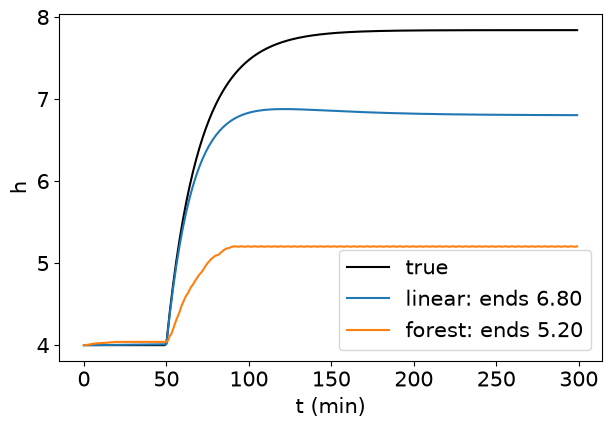

In [15]:
qt = np.where(np.arange(300) < 50, 1.0, 1.4)
ht = tank(qt, 300)
fig, ax = plt.subplots(figsize=(7, 4.5)); ax.plot(ht, "k", label="true")
for name, m in [("linear", lin), ("forest", rf)]:
    hh = list(ht[:2])
    for k in range(2, 300):
        x = pd.DataFrame([[hh[-1], hh[-2], qt[k-1], qt[k-2]]],
                         columns=X.columns)
        hh.append(m.predict(x)[0])
    ax.plot(hh, label=f"{name}: ends {hh[-1]:.2f}")
ax.set(xlabel="t (min)", ylabel="h"); ax.legend(); plt.show()

**Code walkthrough.** The test step leaves the training range. Each model is run as a
simulator: start from two true levels, then predict the next level
from its own previous predictions -- as a model inside a controller
would. True level ends at 7.84. Linear ends at 6.80: right direction,
gain too small (one gain, 7.0, fitted over the training range). The forest stalls at 5.20, below
its training ceiling: it cannot extrapolate. Same R^2, very different
fitness for control.

### Your Turn (6 min)

Read the code: what does this print?

```python
s = pd.Series([1.0, 2.0, 3.0])
print(s.shift(1).tolist())
```

In Code 1/3, why is `df.h.shift(1)` the right feature for predicting
`df.h`, and `df.h.shift(-1)` the wrong one?

[nan, 1.0, 2.0]. shift(1) puts the previous value on each row: a
feature available at prediction time. shift(-1) would put the *next*
value on the row -- using the answer to predict itself (leakage):
perfect training score, useless model.

### Check -- cold-call

A colleague reports a neural-network model of the reactor with test
$R^2 = 0.998$ and wants to put it in the MPC. What two questions do you
ask first?

(1) Was the test data from operating conditions the controller will
visit (or only a random split of the same runs)? (2) Does the model
work as a multi-step simulator, with its own predictions fed back, and
does it give the right gain sign and size -- what a controller uses?

### Wrap-up

**Derived, then coded:** ISE, IAE, ITAE; Z-N and C-C for Ex. 18.4
(C-C from a tangent is unstable; from a least-squares fit it is
fine); minimum-ITAE tuning; step, pulse and doublet fits; ARX by the
normal equations; a linear and a random-forest model tested outside
their data.

**Tools:** `np.gradient`, `minimize`, `curve_fit`, `np.linalg.lstsq`,
`pd.DataFrame.shift`, `LinearRegression`, `RandomForestRegressor`

**Next:** Ch. 20 -- cascade, feedforward, ratio control.